# 15 · High-temperature thermochemistry: combustion and metals

Burning fuels and reducing ores are the two oldest high-temperature industries, and both are governed by
the same quantities: reaction enthalpies for the heat released and Gibbs energies for what can react at all.
This notebook computes heating values and flame temperatures, compares fuels by their CO$_2$ emissions, and
uses the Ellingham diagram to explain how metals are won from their oxides - and why hydrogen may replace
carbon in making steel.

**What you will learn**
- compute heating values and CO2 intensities of fuels
- calculate adiabatic flame temperatures with variable heat capacities
- read and use an Ellingham diagram
- explain carbothermic and hydrogen reduction of metal oxides

**Before you start:** notebooks 01 and 14  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import combustion, components, reaction
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Heating values and CO$_2$ intensity of fuels

In [2]:
rows = []
for fuel in ("H2", "CH4", "propane", "n-octane", "methanol", "ethanol"):
    hv = combustion.heating_values(fuel)
    M = components.get(fuel).M
    co2 = combustion.stoichiometry(fuel)["CO2"] * 44.01e-3
    rows.append((fuel, hv["LHV"] / 1e3, hv["HHV"] / 1e3, hv["LHV"] / M / 1e6, co2 / (hv["LHV"] / 1e6) * 1e3))
print(pd.DataFrame(rows, columns=["fuel", "LHV (kJ/mol)", "HHV (kJ/mol)", "LHV (MJ/kg)", "g CO2 per MJ (LHV)"]).round(1).to_string(index=False))

    fuel  LHV (kJ/mol)  HHV (kJ/mol)  LHV (MJ/kg)  g CO2 per MJ (LHV)
      H2         241.8         285.8        120.0                 0.0
     CH4         802.6         890.6         50.0                54.8
 propane        2043.1        2219.2         46.3                64.6
n-octane        5115.7        5511.8         44.8                68.8
methanol         676.5         764.5         21.1                65.1
 ethanol        1277.4        1409.4         27.7                68.9


Per kilogram, hydrogen carries almost three times the energy of hydrocarbons and emits no CO$_2$ at the
point of use; methane emits a quarter less CO$_2$ per megajoule than octane, the basis of coal-to-gas and
oil-to-gas switching; alcohols sit in between. The difference between HHV and LHV is the latent heat of
the water formed - recoverable only if the flue gas is cooled below its dew point (condensing boilers).

## The adiabatic flame temperature
If no heat is lost, all of the heat released goes into the products:

CH4     : adiabatic flame temperature in stoichiometric air 2333 K
H2      : adiabatic flame temperature in stoichiometric air 2519 K
propane : adiabatic flame temperature in stoichiometric air 2402 K


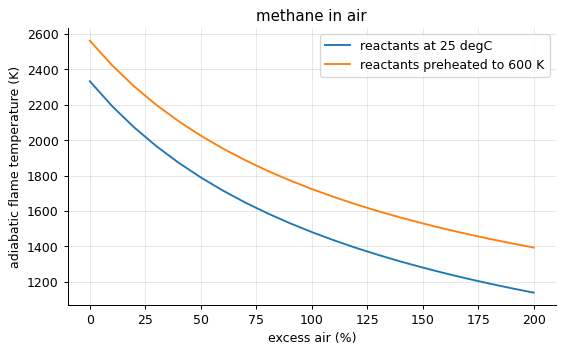

In [3]:
for fuel in ("CH4", "H2", "propane"):
    print(f"{fuel:<8}: adiabatic flame temperature in stoichiometric air {combustion.adiabatic_flame_temperature(fuel)['T_ad']:.0f} K")
excess = np.linspace(0, 2.0, 21)
T_ad = [combustion.adiabatic_flame_temperature("CH4", e)["T_ad"] for e in excess]
T_pre = [combustion.adiabatic_flame_temperature("CH4", e, T_in=600.0)["T_ad"] for e in excess]
plt.plot(excess * 100, T_ad, label="reactants at 25 degC"); plt.plot(excess * 100, T_pre, label="reactants preheated to 600 K")
plt.xlabel("excess air (%)"); plt.ylabel("adiabatic flame temperature (K)"); plt.title("methane in air"); plt.legend(); plt.show()

Excess air dilutes the flame - a furnace at 100 % excess air is 500 K cooler - while preheating the
combustion air (with heat recovered from the flue gas) raises it. Both are levers in furnace design: the
first keeps NO$_x$ formation and materials within limits, the second saves fuel. These temperatures ignore
dissociation of CO$_2$ and H$_2$O, which caps real flames about 100-200 K lower.

## The Ellingham diagram
For the oxidation of metals and of carbon, the standard Gibbs energy per mole of O$_2$ against temperature:

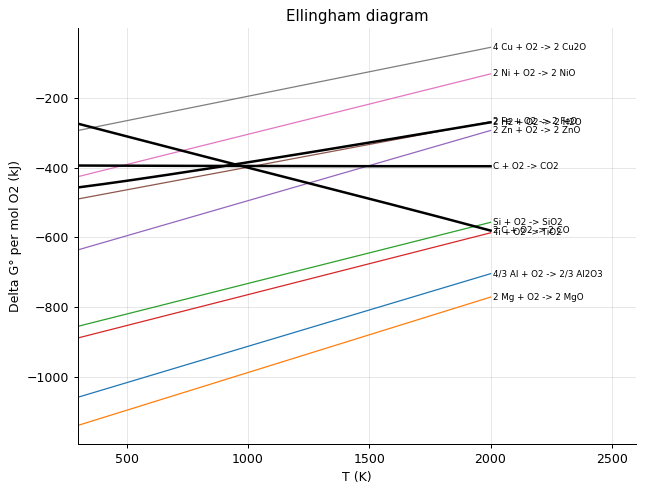

In [4]:
T = np.linspace(300, 2000, 200)
lines = combustion.ellingham(T)
fig, ax = plt.subplots(figsize=(8, 6))
for name, dG in lines.items():
    style = "k" if name.startswith(("2 C", "C ", "2 H2")) else None
    ax.plot(T, dG / 1e3, color=style, lw=2 if style else 1)
    ax.text(T[-1] + 10, dG[-1] / 1e3, name, fontsize=7, va="center")
ax.set(xlabel="T (K)", ylabel="Delta G° per mol O2 (kJ)", title="Ellingham diagram", xlim=(300, 2600)); plt.show()

Every line slopes upward - oxidation consumes gas, losing entropy - except the C + O$_2$ line for CO, which
*produces* gas and slopes downward. That single fact made the industrial revolution: at high enough
temperature carbon's line crosses below any metal oxide's, so carbon (coke) can reduce it. The lower a
metal's line, the more stable its oxide and the harder the metal is to win:

In [5]:
from scipy import optimize
def crossing(metal_line):
    f = lambda T_: combustion.ellingham(T_)["2 C + O2 -> 2 CO"][0] - combustion.ellingham(T_)[metal_line][0]
    try:
        return optimize.brentq(f, 300, 3000)
    except ValueError:
        return np.nan
for metal in ("4 Cu + O2 -> 2 Cu2O", "2 Ni + O2 -> 2 NiO", "2 Fe + O2 -> 2 FeO", "2 Zn + O2 -> 2 ZnO", "Si + O2 -> SiO2", "2 Mg + O2 -> 2 MgO", "4/3 Al + O2 -> 2/3 Al2O3"):
    Tc = crossing(metal)
    print(f"{metal:<26}: carbon reduces the oxide above {Tc:5.0f} K" if np.isfinite(Tc) else f"{metal:<26}: not reducible by carbon below 3000 K")

4 Cu + O2 -> 2 Cu2O       : carbon reduces the oxide above   360 K
2 Ni + O2 -> 2 NiO        : carbon reduces the oxide above   729 K
2 Fe + O2 -> 2 FeO        : carbon reduces the oxide above   995 K
2 Zn + O2 -> 2 ZnO        : carbon reduces the oxide above  1250 K
Si + O2 -> SiO2           : carbon reduces the oxide above  1935 K
2 Mg + O2 -> 2 MgO        : carbon reduces the oxide above  2465 K
4/3 Al + O2 -> 2/3 Al2O3  : carbon reduces the oxide above  2309 K


Copper and nickel are easy, iron needs a blast furnace at over 1000 K, zinc and silicon need more; magnesium
and aluminium cannot be won with carbon at any practical temperature - which is why aluminium is made by
electrolysis (notebook 16) and why it was a precious metal until 1886. The equilibrium oxygen partial pressure
of each line, $p_{O_2} = \exp(\Delta G^\circ/RT)$, shows how oxygen-free a furnace atmosphere must be:

In [6]:
for name in ("2 Fe + O2 -> 2 FeO", "2 Mg + O2 -> 2 MgO"):
    pO2 = combustion.oxygen_partial_pressure(combustion.ellingham(1000.0)[name][0], 1000.0)
    print(f"{name}: equilibrium p_O2 at 1000 K = {pO2:.1e} bar")

2 Fe + O2 -> 2 FeO: equilibrium p_O2 at 1000 K = 1.4e-21 bar
2 Mg + O2 -> 2 MgO: equilibrium p_O2 at 1000 K = 2.8e-52 bar


## Hydrogen as a reductant: green steel
Hydrogen's line also rises with temperature, like a metal's. Where it crosses the iron line, hydrogen can
reduce iron oxide:

In [7]:
f = lambda T_: combustion.ellingham(T_)["2 H2 + O2 -> 2 H2O"][0] - combustion.ellingham(T_)["2 Fe + O2 -> 2 FeO"][0]
T_cross = optimize.brentq(f, 300, 2500)
print(f"hydrogen reduces FeO above about {T_cross:.0f} K; at 1200 K the equilibrium H2O/H2 ratio is "
      f"{np.exp(-f(1200.0) / (2 * R * 1200.0)):.2f}")

hydrogen reduces FeO above about 1877 K; at 1200 K the equilibrium H2O/H2 ratio is 0.60


Direct reduction of iron ore with hydrogen is thermodynamically possible at furnace temperatures, with
water as the only by-product - the route to "green" steel if the hydrogen itself is made without CO$_2$.
The equilibrium H$_2$O/H$_2$ ratio limits how much of the hydrogen is used per pass, so the gas is recycled
after drying: the same thermodynamic ceiling and recycle logic as the ammonia loop of notebook 14.

## Inside the algorithm: the flame-temperature energy balance
The products' sensible enthalpy above 25 degC must equal the lower heating value; solve for T:

In [8]:
from scipy import optimize
from engthermo import idealgas
prod = combustion.flue_gas("CH4"); q = combustion.heating_values("CH4")["LHV"]
f = lambda T_: sum(n * idealgas.enthalpy_change(s, 298.15, T_) for s, n in prod.items() if n > 0) - q
print(f"by hand: T_ad = {optimize.brentq(f, 298.15, 4000):.1f} K;  library: {combustion.adiabatic_flame_temperature('CH4')['T_ad']:.1f} K")

by hand: T_ad = 2332.6 K;  library: 2332.6 K


## Exercises
1. A gas turbine burns methane with 200 % excess air and reactants preheated to 700 K. Find the flame temperature, and the excess air needed to keep it at 1800 K (a typical turbine-inlet limit).
2. From the Ellingham diagram, at what temperature does the C/CO line cross the Si/SiO2 line? Compare with the operating temperature of a silicon smelting furnace (about 2000 K). Why is aluminium produced electrolytically instead?
3. **Implement it yourself:** compute the CO2 emitted per MJ of heat for a coal approximated as pure carbon (LHV from the formation enthalpy of CO2), and compare with methane. What is the ratio?